<img src="https://www.unad.edu.co/images/footer/logo-unad-acreditacion-min.png" width="780" height="140" align="right"/>

<p style="text-align: center;"> Course: Advanced Machine Learning</p>

<p style="text-align: center;"> Course code: 203238427 </p>

<p style="text-align: center;"> Group: 01 </p>

<p style="text-align: center;"> Phase 3 - Ensemble learning</p>

<p style="text-align: center;">  Presented by: Jerónimo Ramos Ruiz </p>

<p style="text-align: center;">  Tutor: Rafael Gaitán Ospina </p>

<p style="text-align: center;"> UNIVERSIDAD NACIONAL ABIERTA Y A DISTANCIA - UNAD </p>

<p style="text-align: center;"> Medellin, March 2026</p>

# Load dataset

In [1]:
from sklearn.datasets import fetch_openml

df_reg = fetch_openml(data_id=560, parser='auto')
df_class = fetch_openml(data_id=37, parser='auto')


In this phase we will use some data from [Open ML](https://www.openml.org/) which is an open platform that allows to share datasets, algorithms and experimets to learn. In this case, we will use two data sets, one related to estimates of the percentage of body fat determined by underwater weighing Bodyfat ([ID: 560](openml.org/search?type=data&status=active&id=560)); and the other to cases of diabetes on a group of females of Pima Indian heritage ([ID: 37](openml.org/search?type=data&status=active&id=560))

In [2]:
# First we will import the main libraries we will need for each function.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    mean_squared_error, mean_absolute_error, r2_score
    )
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import learning_curve

In [3]:
# In all exercises we will need to calculate the metrics of each model and the learning curves
# with this in mind, we will be creating some functions to easy calculate them

def classification_metrics(y_true, y_pred, model_name="Model"):
    """
    Calculate and display classification metrics.
    
    Parameters:
    -----------
    y_true : array-like  — True labels
    y_pred : array-like  — Predicted labels
    model_name : str     — Label to display
    
    Returns:
    --------
    dict with metric names and values
    """
    metrics = {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'recall':    recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'f1_score':  f1_score(y_true, y_pred, average='weighted', zero_division=0),
    }
    
    print(f"\n{'='*50}")
    print(f"  Classification Metrics — {model_name}")
    print(f"{'='*50}")
    
    for name, value in metrics.items():
        print(f"  {name.capitalize():<12}: {value:.4f}")
    print(f"{'='*50}")
    
    return metrics


def regression_metrics(y_true, y_pred, model_name="Model"):
    """
    Calculate and display regression metrics.
    
    Parameters:
    -----------
    y_true : array-like  — True values
    y_pred : array-like  — Predicted values
    model_name : str     — Label to display
    
    Returns:
    --------
    dict with metric names and values
    """
    metrics = {
        'mse': mean_squared_error(y_true, y_pred),
        'mae': mean_absolute_error(y_true, y_pred),
        'r2':  r2_score(y_true, y_pred),
    }
    
    print(f"\n{'='*50}")
    print(f"  Regression Metrics — {model_name}")
    print(f"{'='*50}")
    
    print(f"  MSE          : {metrics['mse']:.4f}")
    print(f"  MAE          : {metrics['mae']:.4f}")
    print(f"  R² Score     : {metrics['r2']:.4f}")
    print(f"{'='*50}")
    
    return metrics

def plot_learning_curve(estimator, X, y, title, cv, scoring, ax=None):
    """
    Plot the learning curve for a given estimator.

    Parameters:
    -----------
    estimator   : sklearn estimator
    X           : feature matrix
    y           : target vector
    title       : str — plot title
    cv          : cross-validation strategy
    scoring     : str — sklearn scoring metric
    ax          : matplotlib Axes (optional)
    """
    train_sizes = np.linspace(0.1, 1.0, 8)
    train_sizes_abs, train_scores, val_scores = learning_curve(
        estimator, X, y,
        cv=cv,
        scoring=scoring,
        train_sizes=train_sizes,
        n_jobs=-1
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std  = np.std(train_scores, axis=1)
    val_mean   = np.mean(val_scores, axis=1)
    val_std    = np.std(val_scores, axis=1)

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(train_sizes_abs, train_mean, 'o-', color='royalblue',  label='Training score')
    ax.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.15, color='royalblue')
    ax.plot(train_sizes_abs, val_mean,   's-', color='tomato', label='Validation score')
    ax.fill_between(train_sizes_abs, val_mean - val_std,   val_mean + val_std,   alpha=0.15, color='tomato')

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Training samples')
    ax.set_ylabel(scoring)
    ax.legend(loc='best')
    ax.grid(alpha=0.3)

    return ax

Since the remaining exercises require a prior process of data selection, separation into a test set and a training set, as well as scaling to improve model performance, these adjustments are made in the following cells to prepare the datasets for use. For this first case, all available variables in each dataset will be considered.

In [5]:
# Now we will split and scale the data for the classification dataset

X_class = df_class['data']
y_class = df_class['target']

y_class = y_class.map({'tested_positive': 1, 'tested_negative': 0})

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X_class, y_class, test_size=0.25, random_state=42)

scaler_class = StandardScaler().set_output(transform="pandas")
X_train_stand_c = scaler_class.fit_transform(X_train_class)
X_test_stand_c  = scaler_class.transform(X_test_class)

print(f"Train size for classification: {X_train_stand_c.shape}, Test size: {X_test_stand_c.shape}")


Train size for classification: (576, 8), Test size: (192, 8)


In [6]:
# And for the regression dataset

X_reg = df_reg['data']
y_reg = df_reg['target']

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, random_state=42)

scaler560 = StandardScaler().set_output(transform="pandas")
X_train_stand_r = scaler560.fit_transform(X_train_reg)
X_test_stand_r  = scaler560.transform(X_test_reg)

print(f"Train size for regression: {X_train_stand_r.shape}, Test size: {X_test_stand_r.shape}")

Train size for regression: (189, 14), Test size: (63, 14)


# Exercise 1: Voting and Stacking.

In [7]:
# Base classifiers (for Voting)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

# Base regressors (for Stacking)
from sklearn.linear_model import Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor

# Ensemble methods
from sklearn.ensemble import VotingClassifier, StackingRegressor

---
## Voting

The idea behind the Voting Classifier is to combine conceptually different machine learning classifiers and use a majority vote (hard vote) or the average predicted probabilities (soft vote) to predict the class labels. Such classifier can be useful for a set of equally well performing models in order to balance out their individual weaknesses. To resume we have:

* **Hard Voting**: The final prediction is the **majority vote** of base classifiers.
Each classifier votes for a class and the class with the most votes wins.

* **Soft Voting**: Each classifier outputs **class probabilities**; these are averaged across classifiers and the class with the highest average probability wins.
Soft voting tends to outperform hard voting when classifiers are well-calibrated.

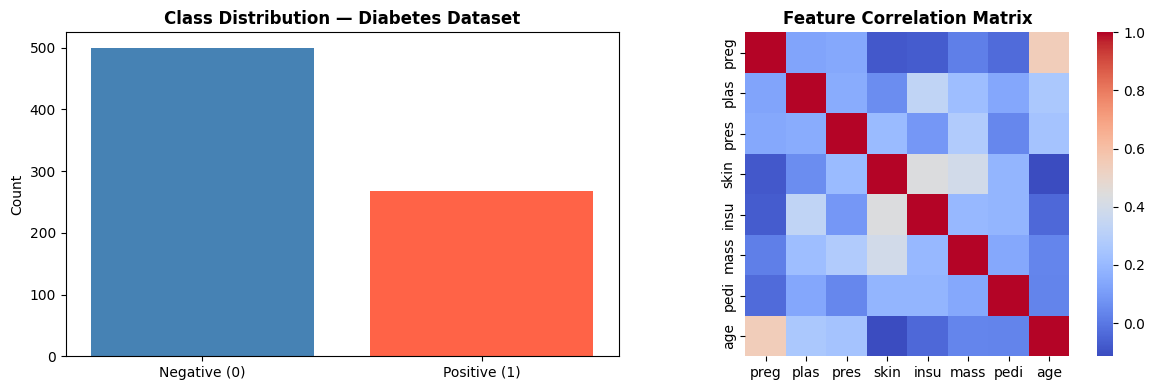

In [8]:
# Quick visual overview
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Class distribution
axes[0].bar(['Negative (0)', 'Positive (1)'], np.bincount(y_class), color=['steelblue', 'tomato'])
axes[0].set_title('Class Distribution — Diabetes Dataset', fontweight='bold')
axes[0].set_ylabel('Count')

# Feature correlation heatmap
corr = X_class.corr()
sns.heatmap(corr, ax=axes[1], cmap='coolwarm', fmt='.1f', annot=False, square=True)
axes[1].set_title('Feature Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.show()

In this case, although several fields with a high correlation are identified that may affect the behavior of the model, a first analysis will be carried out with all variables to identify the ability of the voting model to improve the individual conditions of the models and obtain a better result.

### Metrics

In [25]:
class_estimators = [
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=42)),
    ("Decision Tree", DecisionTreeClassifier(max_depth=5, random_state=42)),
    ("K-Neighbors", KNeighborsClassifier(n_neighbors=7))
]

# Train and evaluate each base classifier individually
print("--- Base Classifier Accuracy on Test Set ---")

for name, model in class_estimators:
    model.fit(X_train_stand_c, y_train_class)
    y_pred = model.predict(X_test_stand_c)
    
    metrics_base = classification_metrics(y_test_class, y_pred, name)


print("--- Base Classifier Accuracy on Test Set ---")
# Hard voting: majority class vote
hard_voter = VotingClassifier(estimators=class_estimators, voting='hard')
hard_voter.fit(X_train_class, y_train_class)
y_pred_hard = hard_voter.predict(X_test_class)

metrics_hard = classification_metrics(y_test_class, y_pred_hard, "Hard Voting")

# Hard voting: majority class vote
soft_voter = VotingClassifier(estimators=class_estimators, voting='soft')
soft_voter.fit(X_train_class, y_train_class)
y_pred_soft = soft_voter.predict(X_test_class)

metrics_soft = classification_metrics(y_test_class, y_pred_soft, "Soft Voting")

--- Base Classifier Accuracy on Test Set ---

  Classification Metrics — Logistic Regression
  Accuracy    : 0.7292
  Precision   : 0.7330
  Recall      : 0.7292
  F1_score    : 0.7307

  Classification Metrics — Decision Tree
  Accuracy    : 0.7240
  Precision   : 0.7215
  Recall      : 0.7240
  F1_score    : 0.7226

  Classification Metrics — K-Neighbors
  Accuracy    : 0.6979
  Precision   : 0.6943
  Recall      : 0.6979
  F1_score    : 0.6958
--- Base Classifier Accuracy on Test Set ---

  Classification Metrics — Hard Voting
  Accuracy    : 0.7240
  Precision   : 0.7249
  Recall      : 0.7240
  F1_score    : 0.7244

  Classification Metrics — Soft Voting
  Accuracy    : 0.7083
  Precision   : 0.7103
  Recall      : 0.7083
  F1_score    : 0.7092


### Learning curves

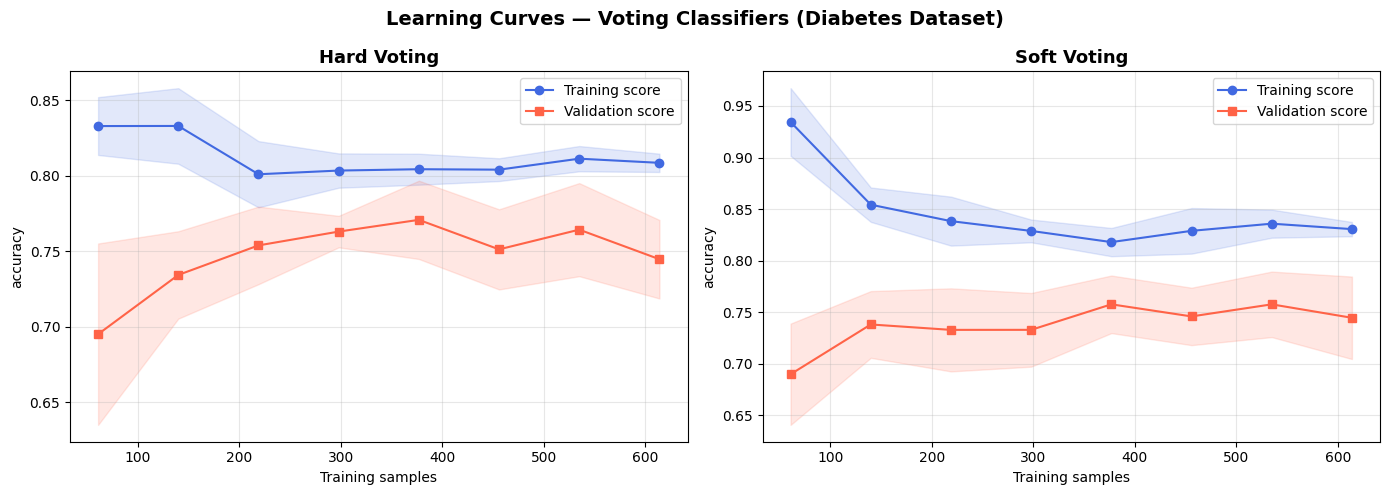

In [26]:
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curves — Voting Classifiers (Diabetes Dataset)', fontsize=14, fontweight='bold')

plot_learning_curve(
    VotingClassifier(estimators=class_estimators, voting='hard'),
    X_class, y_class,
    title='Hard Voting',
    cv=cv_strat,
    scoring='accuracy',
    ax=axes[0]
)

plot_learning_curve(
    VotingClassifier(estimators=class_estimators, voting='soft'),
    X_class, y_class,
    title='Soft Voting',
    cv=cv_strat,
    scoring='accuracy',
    ax=axes[1]
)

plt.tight_layout()
plt.show()

In this case, no significant improvements in the accuracy of the individual models are observed. Furthermore, based on the learning curves, we can identify that the model exhibits overfitting, showing high accuracy in the test set but seemingly inferior performance in the validation set. This could be because the previously identified correlated variables introduce noise into the model, causing it to memorize the results instead of learning and generalizing from them.

Taking this into account, the variables that had the greatest impact on the models in previous releases were selected, as shown below:

In [11]:
X_class_adj = df_class['data'][['plas', 'mass']]
y_class = df_class['target']

y_class = y_class.map({'tested_positive': 1, 'tested_negative': 0})

X_train_class_adj, X_test_class_adj, y_train_class, y_test_class = train_test_split(X_class_adj, y_class, test_size=0.25, random_state=42)

scaler_class = StandardScaler().set_output(transform="pandas")
X_train_stand_c_adj = scaler_class.fit_transform(X_train_class_adj)
X_test_stand_c_adj = scaler_class.transform(X_test_class_adj)

print(f"Train size for classification: {X_train_stand_c_adj.shape}, Test size: {X_test_stand_c_adj.shape}")

Train size for classification: (576, 2), Test size: (192, 2)


In [12]:
class_estimators = [
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=42)),
    ("Decision Tree", DecisionTreeClassifier(max_depth=5, random_state=42)),
    ("K-Neighbors", KNeighborsClassifier(n_neighbors=7))
]

# Train and evaluate each base classifier individually
print("--- Base Classifier Accuracy on Test Set ---")

for name, model in class_estimators:
    model.fit(X_train_stand_c_adj, y_train_class)
    y_pred = model.predict(X_test_stand_c_adj)
    
    metrics_base = classification_metrics(y_test_class, y_pred, name)


print("--- Base Classifier Accuracy on Test Set ---")
# Hard voting: majority class vote
hard_voter = VotingClassifier(estimators=class_estimators, voting='hard')
hard_voter.fit(X_train_class_adj, y_train_class)
y_pred_hard = hard_voter.predict(X_test_class_adj)

metrics_hard = classification_metrics(y_test_class, y_pred_hard, "Hard Voting")

# Hard voting: majority class vote
soft_voter = VotingClassifier(estimators=class_estimators, voting='soft')
soft_voter.fit(X_train_class_adj, y_train_class)
y_pred_soft = soft_voter.predict(X_test_class_adj)

metrics_soft = classification_metrics(y_test_class, y_pred_soft, "Soft Voting")

--- Base Classifier Accuracy on Test Set ---

  Classification Metrics — Logistic Regression
  Accuracy    : 0.7448
  Precision   : 0.7395
  Recall      : 0.7448
  F1_score    : 0.7404

  Classification Metrics — Decision Tree
  Accuracy    : 0.7292
  Precision   : 0.7228
  Recall      : 0.7292
  F1_score    : 0.7239

  Classification Metrics — K-Neighbors
  Accuracy    : 0.7448
  Precision   : 0.7385
  Recall      : 0.7448
  F1_score    : 0.7379
--- Base Classifier Accuracy on Test Set ---

  Classification Metrics — Hard Voting
  Accuracy    : 0.7344
  Precision   : 0.7279
  Recall      : 0.7344
  F1_score    : 0.7286

  Classification Metrics — Soft Voting
  Accuracy    : 0.7396
  Precision   : 0.7331
  Recall      : 0.7396
  F1_score    : 0.7332


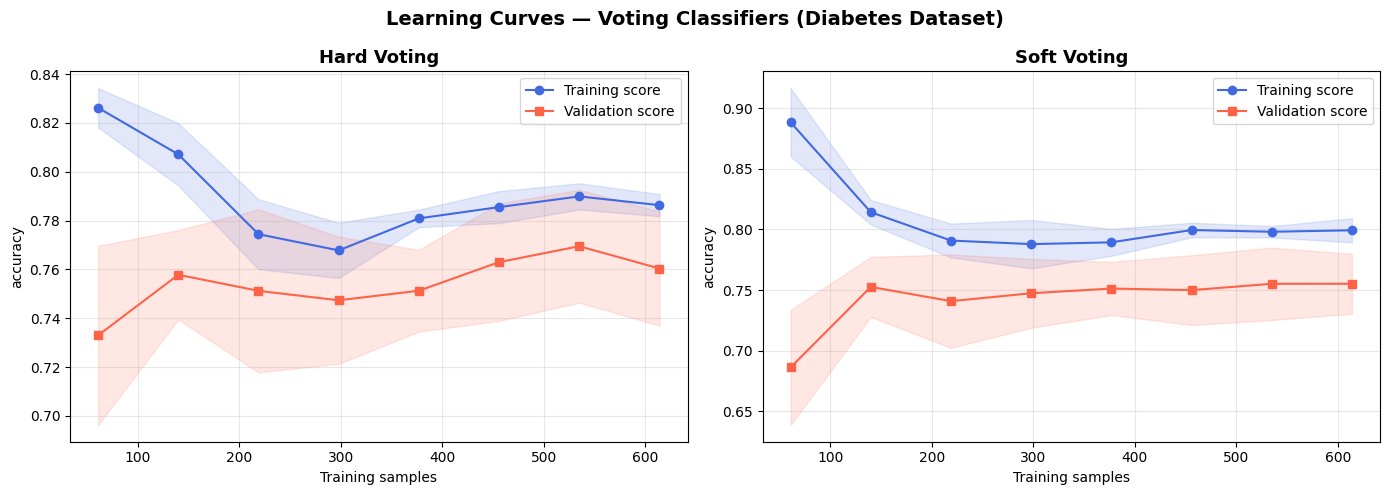

In [14]:
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learning Curves — Voting Classifiers (Diabetes Dataset)', fontsize=14, fontweight='bold')

plot_learning_curve(
    VotingClassifier(estimators=class_estimators, voting='hard'),
    X_class_adj, y_class,
    title='Hard Voting',
    cv=cv_strat,
    scoring='accuracy',
    ax=axes[0]
)

plot_learning_curve(
    VotingClassifier(estimators=class_estimators, voting='soft'),
    X_class_adj, y_class,
    title='Soft Voting',
    cv=cv_strat,
    scoring='accuracy',
    ax=axes[1]
)

plt.tight_layout()
plt.show()

In this case, an improvement in the learning curves of both models is observed. While the training model starts with high accuracy and the validation model with low accuracy, a point is reached where both records converge and maintain a constant distance between them, indicating an improvement in the model's generalizability in both cases. However, the accuracy of the voting model does not show an improvement compared to the individual models.

## Stacking

**Stacking** (Stacked Generalization) uses predictions from **level-0 (base) models** as features for a **level-1 (meta) model**.
Base models are trained on the full training set using **k-fold cross-validation** to generate out-of-fold predictions, which prevents data leakage.


In [27]:

print(f"  Shape       : {X_reg.shape}")
print(f"  Target range: [{y_reg.min():.2f}, {y_reg.max():.2f}]")
print(f"  Target mean : {y_reg.mean():.2f}, std: {y_reg.std():.2f}")

  Shape       : (252, 14)
  Target range: [0.00, 47.50]
  Target mean : 19.15, std: 8.37


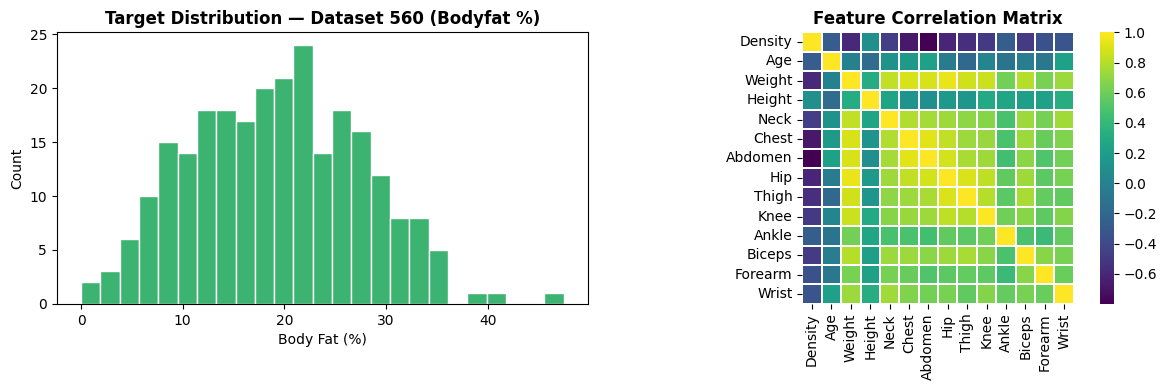

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_reg, bins=25, color='mediumseagreen', edgecolor='white')
axes[0].set_title('Target Distribution — Dataset 560 (Bodyfat %)', fontweight='bold')
axes[0].set_xlabel('Body Fat (%)')
axes[0].set_ylabel('Count')

corr560 = X_reg.corr()
sns.heatmap(corr560, ax=axes[1], cmap='viridis', square=True, linewidths=0.3)
axes[1].set_title('Feature Correlation Matrix', fontweight='bold')

plt.tight_layout()
plt.show()

As in the voting model, in the stacking model all data will initially be used, even though its behavior has already been observed when variables that are highly correlated are introduced, such as those identified in the correlation matrix presented above.

### Metrics

In [16]:
# Level-0 base estimators — diverse to reduce correlation
estimators_reg = [
    ('ridge',  Ridge(alpha=1.0)),
    ('lasso',  Lasso(alpha=0.1, max_iter=5000)),
    ('dt',     DecisionTreeRegressor(max_depth=5, random_state=42))
]

# Level-1 meta-learner (blender)
# Ridge is a robust, low-variance choice for the meta-learner
meta_learner = Ridge(alpha=1.0)

# Train and evaluate base regressors individually
print("--- Base Regressor R² on Test Set ---")
for name, reg in estimators_reg:
    reg.fit(X_train_stand_r, y_train_reg)
    pred = reg.predict(X_test_stand_r)
    basic_metrics = regression_metrics(y_test_reg, pred, name)


stacking_reg = StackingRegressor(
    estimators=estimators_reg,
    final_estimator=meta_learner,
    cv=5,                     # 5-fold CV for OOF predictions
    passthrough=False,         # Set True to also pass original features to meta-learner
    n_jobs=-1
)

stacking_reg.fit(X_train_stand_r, y_train_reg)
y_pred_stack = stacking_reg.predict(X_test_stand_r)

metrics_stack = regression_metrics(y_test_reg, y_pred_stack, "Stacking Regressor")

--- Base Regressor R² on Test Set ---

  Regression Metrics — ridge
  MSE          : 0.4573
  MAE          : 0.5264
  R² Score     : 0.9917

  Regression Metrics — lasso
  MSE          : 0.3113
  MAE          : 0.4700
  R² Score     : 0.9943

  Regression Metrics — dt
  MSE          : 0.5177
  MAE          : 0.5413
  R² Score     : 0.9906

  Regression Metrics — Stacking Regressor
  MSE          : 0.1749
  MAE          : 0.3410
  R² Score     : 0.9968


### Learning curves

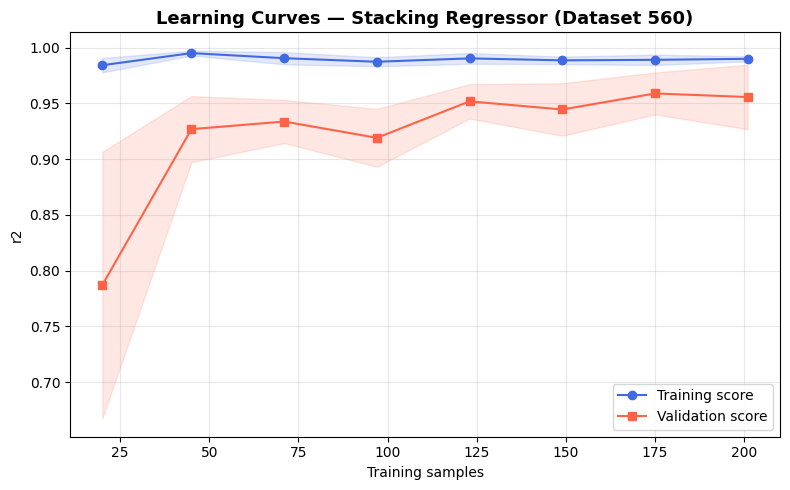

In [38]:
cv_kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Stacking
plot_learning_curve(
    StackingRegressor(estimators=estimators_reg, final_estimator=Ridge(), cv=5),
    X_reg, y_reg,
    title='Learning Curves — Stacking Regressor (Dataset 560)',
    cv=cv_kf,
    scoring='r2'
)

plt.tight_layout()
plt.show()

In this case, we can clearly see that the model is overfitted, since in the training dataset it appears to have a high, almost perfect fit, while in the validation dataset, although it is high, it does not reach a point of equilibrium with the training dataset. Taking this into account, the data will be modified to reduce the number of variables, decreasing the complexity of the model and seeking to improve the behavior of the learning curve so that the model can better generalize the results.

In [25]:
X_reg_adj = df_reg['data'][['Abdomen', 'Density', 'Age']]
y_reg = df_reg['target']

X_train_reg_adj, X_test_reg_adj, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, random_state=42)

scaler560 = StandardScaler().set_output(transform="pandas")
X_train_stand_r_adj = scaler560.fit_transform(X_train_reg_adj)
X_test_stand_r_adj  = scaler560.transform(X_test_reg_adj)

print(f"Train size for regression: {X_train_stand_r_adj.shape}, Test size: {X_test_stand_r_adj.shape}")

Train size for regression: (189, 14), Test size: (63, 14)


In [26]:
# Level-0 base estimators — diverse to reduce correlation
estimators_reg = [
    ('ridge',  Ridge(alpha=1.0)),
    ('lasso',  Lasso(alpha=0.1, max_iter=5000)),
    ('dt',     DecisionTreeRegressor(max_depth=5, random_state=42))
]

# Level-1 meta-learner (blender)
# Ridge is a robust, low-variance choice for the meta-learner
meta_learner = Ridge(alpha=1.0)

# Train and evaluate base regressors individually
print("--- Base Regressor R² on Test Set ---")
for name, reg in estimators_reg:
    reg.fit(X_train_stand_r_adj, y_train_reg)
    pred = reg.predict(X_test_stand_r_adj)
    basic_metrics = regression_metrics(y_test_reg, pred, name)


stacking_reg = StackingRegressor(
    estimators=estimators_reg,
    final_estimator=meta_learner,
    cv=5,                     # 5-fold CV for OOF predictions
    passthrough=False,         # Set True to also pass original features to meta-learner
    n_jobs=-1
)

stacking_reg.fit(X_train_stand_r_adj, y_train_reg)
y_pred_stack = stacking_reg.predict(X_test_stand_r_adj)

metrics_stack = regression_metrics(y_test_reg, y_pred_stack, "Stacking Regressor")

--- Base Regressor R² on Test Set ---

  Regression Metrics — ridge
  MSE          : 0.4573
  MAE          : 0.5264
  R² Score     : 0.9917

  Regression Metrics — lasso
  MSE          : 0.3113
  MAE          : 0.4700
  R² Score     : 0.9943

  Regression Metrics — dt
  MSE          : 0.5177
  MAE          : 0.5413
  R² Score     : 0.9906

  Regression Metrics — Stacking Regressor
  MSE          : 0.1749
  MAE          : 0.3410
  R² Score     : 0.9968


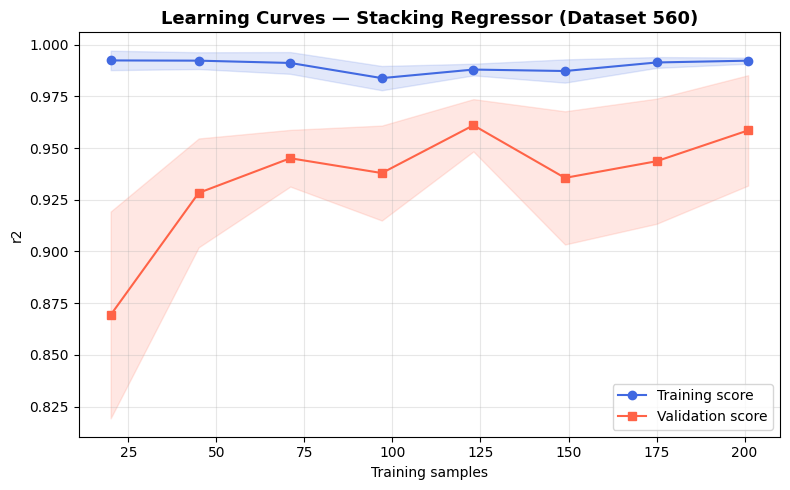

In [39]:
cv_kf = KFold(n_splits=5, shuffle=True, random_state=42)


# Stacking
plot_learning_curve(
    StackingRegressor(estimators=estimators_reg, final_estimator=Ridge(), cv=5),
    X_reg_adj, y_reg,
    title='Learning Curves — Stacking Regressor (Dataset 560)',
    cv=cv_kf,
    scoring='r2'
)

plt.tight_layout()
plt.show()

In this case, a slight improvement in the learning curve is observed, where the error of the validation set appears to have decreased and is approaching the error of the training set, which also showed a slight decrease. It is important to note that the individual models also exhibit a low level of error, so the stacking model cannot show further improvement.

## Conclusions

- While voting and stacking models can improve the performance of individual models, the noise introduced by correlated variables still affects model performance and its ability to generalize responses and learn from the data appropriately.
- On the other hand, some models may be exerting a greater influence on others, either because of their individual ability to learn from data or because of the internal complexity of each one.

# Exercise 2: Bagging.

In [29]:
from sklearn.model_selection import (
    StratifiedKFold, KFold, cross_val_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.linear_model import LogisticRegression

# ── Ensemble Methods
from sklearn.ensemble import (
    BaggingClassifier,
    BaggingRegressor
)


**Bootstrap AGGregatING (Bagging)** trains *B* independent base learners on **bootstrap samples** (random draws with replacement) and averages their predictions. With this technique we want to reduce **variance** without increasing bias, so we will not overfit the model.


$$\hat{f}_{\text{bag}}(x) = \frac{1}{B}\sum_{b=1}^{B} \hat{f}_b(x)$$

The idea is to define multiple models that are trained by random subsets of the original training data. Those random subsets are called *bags* and can contain any combination of the data. Each of those datasets is then used to fit an individual model which produces individual predictions for the given data. Those predictions are then aggregated into one final classifier.

In [30]:
bag_clf = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=None, random_state=42),
    n_estimators=10,
    max_samples=1.0,          # each bootstrap sample is same size as training set
    bootstrap=True,           # sampling WITH replacement
    oob_score=True,           # use out-of-bag samples for free validation
    n_jobs=-1,
    random_state=42
)

cv_clf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
bag_clf.fit(X_train_stand_c_adj, y_train_class)
yp_bag_c = bag_clf.predict(X_test_stand_c_adj)


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_bagging.py:865: UserWarning: Some inputs do not have OOB scores. This probably means too few estimators were used to compute any reliable oob estimates.
  warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_bagging.py:871: RuntimeWarning: invalid value encountered in divide
  oob_decision_function = predictions / predictions.sum(axis=1)[:, np.newaxis]


In [32]:
bag_reg = BaggingRegressor(
    estimator= DecisionTreeRegressor(max_depth=5, random_state=42),
    n_estimators=10,
    max_samples=1.0,          # each bootstrap sample is same size as training set
    bootstrap=True,           # sampling WITH replacement
    oob_score=True,           # use out-of-bag samples for free validation
    n_jobs=-1,
    random_state=42
)

cv_reg = KFold(n_splits=5, shuffle=True, random_state=42)
bag_reg.fit(X_train_stand_r_adj, y_train_reg)
yp_bag_r = bag_reg.predict(X_test_stand_r_adj)

## Metrics

In [33]:
metrics_bag_c  = classification_metrics(y_test_class, yp_bag_c, "Bagging Classifier")

clf_results = []
clf_results.append({'Model': 'Bagging', **metrics_bag_c})

print(f"\n  OOB Score (free validation estimate): {bag_clf.oob_score_:.4f}")


  Classification Metrics — Bagging Classifier
  Accuracy    : 0.6979
  Precision   : 0.6900
  Recall      : 0.6979
  F1_score    : 0.6920

  OOB Score (free validation estimate): 0.7188


In [34]:
metrics_bag_r  = regression_metrics(y_test_reg, yp_bag_r, "Bagging Classifier")

clf_results = []
clf_results.append({'Model': 'Bagging', **metrics_bag_r})

print(f"\n  OOB Score (free validation estimate): {bag_reg.oob_score_:.4f}")


  Regression Metrics — Bagging Classifier
  MSE          : 0.2747
  MAE          : 0.3552
  R² Score     : 0.9950

  OOB Score (free validation estimate): 0.9476


## Learning curves

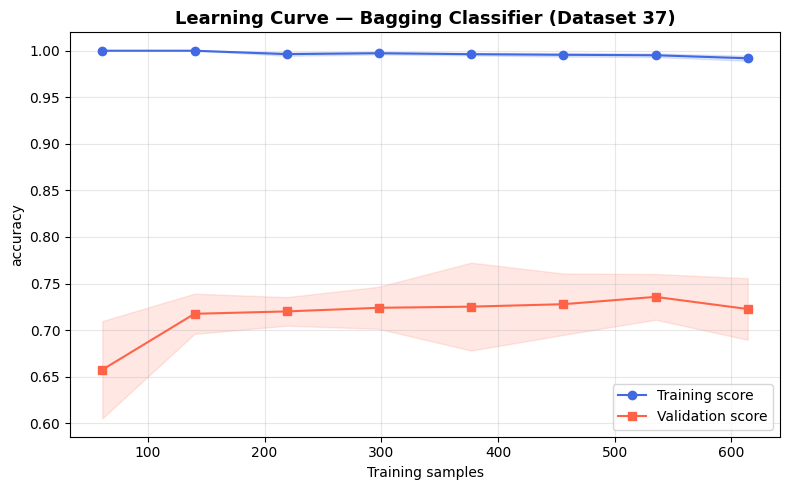

In [36]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_learning_curve(
    BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=200, bootstrap=True, oob_score=False,
        n_jobs=-1, random_state=42
    ),
    X_class_adj, y_class,
    title='Learning Curve — Bagging Classifier (Dataset 37)',
    cv=cv_clf, scoring='accuracy', ax=ax
)
plt.tight_layout()
plt.show()

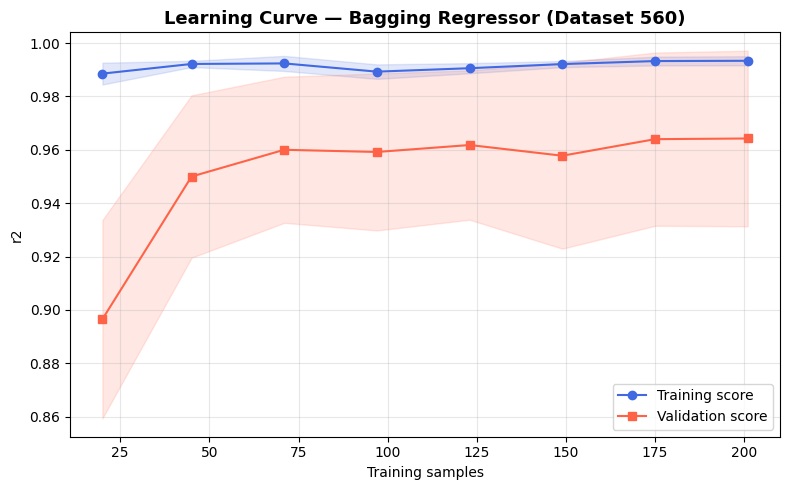

In [46]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_learning_curve(
    BaggingRegressor(
        estimator= DecisionTreeRegressor(max_depth=5, random_state=42),
        n_estimators=10,
        max_samples=1.0,          # each bootstrap sample is same size as training set
        bootstrap=True,           # sampling WITH replacement
        oob_score=True,           # use out-of-bag samples for free validation
        n_jobs=-1,
        random_state=42
    ),
    X_reg_adj, y_reg,
    title='Learning Curve — Bagging Regressor (Dataset 560)',
    cv=cv_reg, scoring='r2', ax=ax
)
plt.tight_layout()
plt.show()

## Conclusions

# Exercise 3: Boosting.

In [48]:
from sklearn.ensemble import (
    AdaBoostClassifier,
    AdaBoostRegressor,
    GradientBoostingRegressor,
    GradientBoostingClassifier,
    RandomForestRegressor,
    BaggingRegressor
)

from xgboost import XGBRegressor, XGBClassifier

## AdaBoost

In [48]:
ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),  # weak learner = stump
    n_estimators=300,
    learning_rate=0.5,   # shrinks each tree's contribution — trades off n_estimators vs learning_rate
    algorithm='SAMME',
    random_state=42
)

ada_clf.fit(X_train_stand_c, y_train_class)
yp_ada_c = ada_clf.predict(X_test_stand_c)
metrics_ada_c  = classification_metrics(y_test_class, yp_ada_c, "AdaBoost")
clf_results.append({'Model': 'AdaBoost', **metrics_ada_c})

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(



  Classification Metrics — AdaBoost
  Accuracy    : 0.7656
  Precision   : 0.7636
  Recall      : 0.7656
  F1_score    : 0.7644


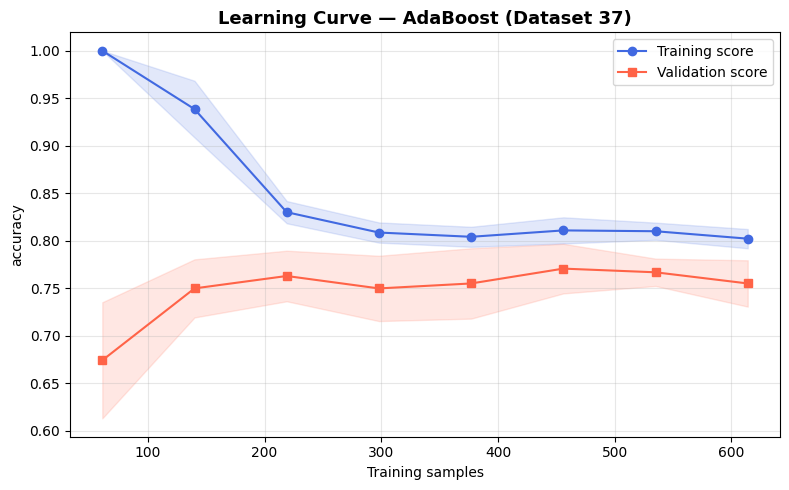

In [43]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_learning_curve(
    AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=300, learning_rate=0.5, algorithm='SAMME', random_state=42
    ),
    X_class, y_class,
    title='Learning Curve — AdaBoost (Dataset 37)',
    cv=cv_clf, scoring='accuracy', ax=ax
)
plt.tight_layout()
plt.show()

In [52]:
ada_reg = AdaBoostRegressor(
    estimator=DecisionTreeRegressor(max_depth=5),  # weak learner = stump
    n_estimators=100,
    learning_rate=0.5,   # shrinks each tree's contribution — trades off n_estimators vs learning_rate
    random_state=42
)

ada_reg.fit(X_train_stand_r, y_train_reg)
yp_ada_r = ada_reg.predict(X_test_stand_r)
metrics_ada_r  = regression_metrics(y_test_reg, yp_ada_r, "AdaBoost")
clf_results.append({'Model': 'AdaBoost', **metrics_ada_r}) 


  Regression Metrics — AdaBoost
  MSE          : 0.1681
  MAE          : 0.2898
  R² Score     : 0.9969


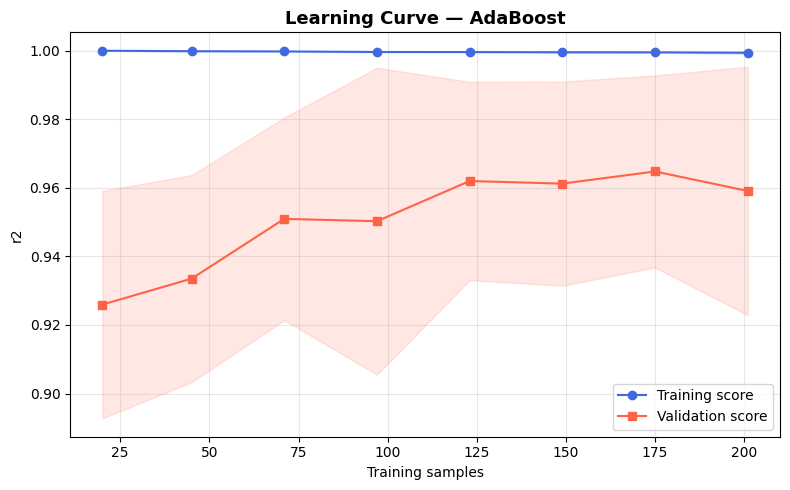

In [49]:
fig, ax = plt.subplots(figsize=(8, 5))
plot_learning_curve(
    AdaBoostRegressor(
        estimator=DecisionTreeRegressor(max_depth=5),
        n_estimators=100, learning_rate=0.5, random_state=42
    ),
    X_reg_adj, y_reg,
    title='Learning Curve — AdaBoost',
    cv=cv_reg, scoring='r2', ax=ax
)
plt.tight_layout()
plt.show()

## Gradient Boosting

## XGBoost

## Conclusions

# Exercise 4: Random Forest.

## Metrics

## Learning curves

## Conclusions

# References

In [ ]:
import bibtexparser

with open("../references.bib", "r", encoding="utf-8") as bib_file:
    bib_database = bibtexparser.load(bib_file)

for i, entry in enumerate(bib_database.entries, 1):
    url = entry.get("url", "unknown")
    authors    = entry.get("author", "Unknown Author")
    title      = entry.get("title", "No Title")
    year       = entry.get("year", "n.d.")
    journal    = entry.get("journal", entry.get("booktitle", ""))
    
    print(f"[{i}] {authors} ({year}). \033[3m{title}\033[0m. {journal} [{url}]")
    print()